# Urban Mobility Simulation: Comparing City Archetypes

This notebook demonstrates the sim-city package by simulating mobility patterns across four urban archetypes:

1. **Monocentric** - Single CBD with concentrated POIs
2. **Polycentric** - Multiple centers with slight CBD emphasis
3. **Composite** - Distributed population, CBD-heavy amenities
4. **Urban Villages** - 16-village grid structure

We'll compare how urban form affects mobility patterns, experienced isolation, and inter-zone exposure.

In [2]:
from sim_city import *

## Configuration

We'll use consistent parameters across all archetypes to ensure fair comparison.

In [3]:
# Shared simulation parameters
N_RESIDENTS = 2000
N_POIS = 300
N_TIMESTEPS = 100
CITY_EXTENT = 10.0  # km

# City archetypes to compare
ARCHETYPES = ['monocentric', 'polycentric', 'composite', 'urban_villages']

print(f"Simulating {N_RESIDENTS} agents, {N_POIS} POIs, {N_TIMESTEPS} timesteps")
print(f"City extent: {CITY_EXTENT} km x {CITY_EXTENT} km")

Simulating 2000 agents, 300 POIs, 100 timesteps
City extent: 10.0 km x 10.0 km


In [4]:
SEED = 42

## Run Simulations

Run mobility simulations for each urban archetype using the EPR (Exploration-Preferential Return) model with capacity constraints.

In [5]:
results = {}

for archetype in ARCHETYPES:
    print(f"\nSimulating {archetype}...")
    
    config = SimulationConfig(
        n_residents=N_RESIDENTS,
        n_pois=N_POIS,
        n_timesteps=N_TIMESTEPS,
        city_extent=CITY_EXTENT,
        destination_model='rank_distance',
        use_epr=True,
        enforce_capacity=True,
        use_returner_explorer=True,
        use_income_stratification=True,
        seed=SEED
    )
    
    sim = MobilitySimulation(config)
    sim.setup(city_type=archetype)
    sim.run()
    
    results[archetype] = sim
    
    # Quick summary
    mean_isolation = sim.isolation_df['experienced_isolation'].mean()
    print(f"  Mean isolation: {mean_isolation:.3f}")

print("\nAll simulations complete!")


Simulating monocentric...
Setting up simulation: Destination: rank_distance | EPR(ρ=0.6, γ=0.21) | Recency(window=5) | Capacity(L=25.0±5.0) | RetExp(frac=0.75)
  Generated 300 POIs
  Generated 2000 agents
  Using rank_distance destination model

Running simulation for 100 timesteps...
  t=   0: isolation=0.488 ± 0.251, locs=1.0, Rg=0.00
  t=   5: isolation=0.419 ± 0.157, locs=3.6, Rg=1.52
  t=  10: isolation=0.408 ± 0.138, locs=5.8, Rg=1.70
  t=  15: isolation=0.400 ± 0.127, locs=7.9, Rg=1.77
  t=  20: isolation=0.394 ± 0.120, locs=9.8, Rg=1.81
  t=  25: isolation=0.390 ± 0.117, locs=11.6, Rg=1.84
  t=  30: isolation=0.385 ± 0.113, locs=13.3, Rg=1.86
  t=  35: isolation=0.381 ± 0.109, locs=15.0, Rg=1.87
  t=  40: isolation=0.379 ± 0.108, locs=16.5, Rg=1.88
  t=  45: isolation=0.377 ± 0.106, locs=18.0, Rg=1.88
  t=  50: isolation=0.376 ± 0.105, locs=19.3, Rg=1.88
  t=  55: isolation=0.374 ± 0.104, locs=20.4, Rg=1.89
  t=  60: isolation=0.373 ± 0.104, locs=21.4, Rg=1.89
  t=  65: isolat

## Visualize Spatial Distributions

Compare how POIs and agents are distributed across the four archetypes.

In [6]:
import matplotlib.pyplot as plt

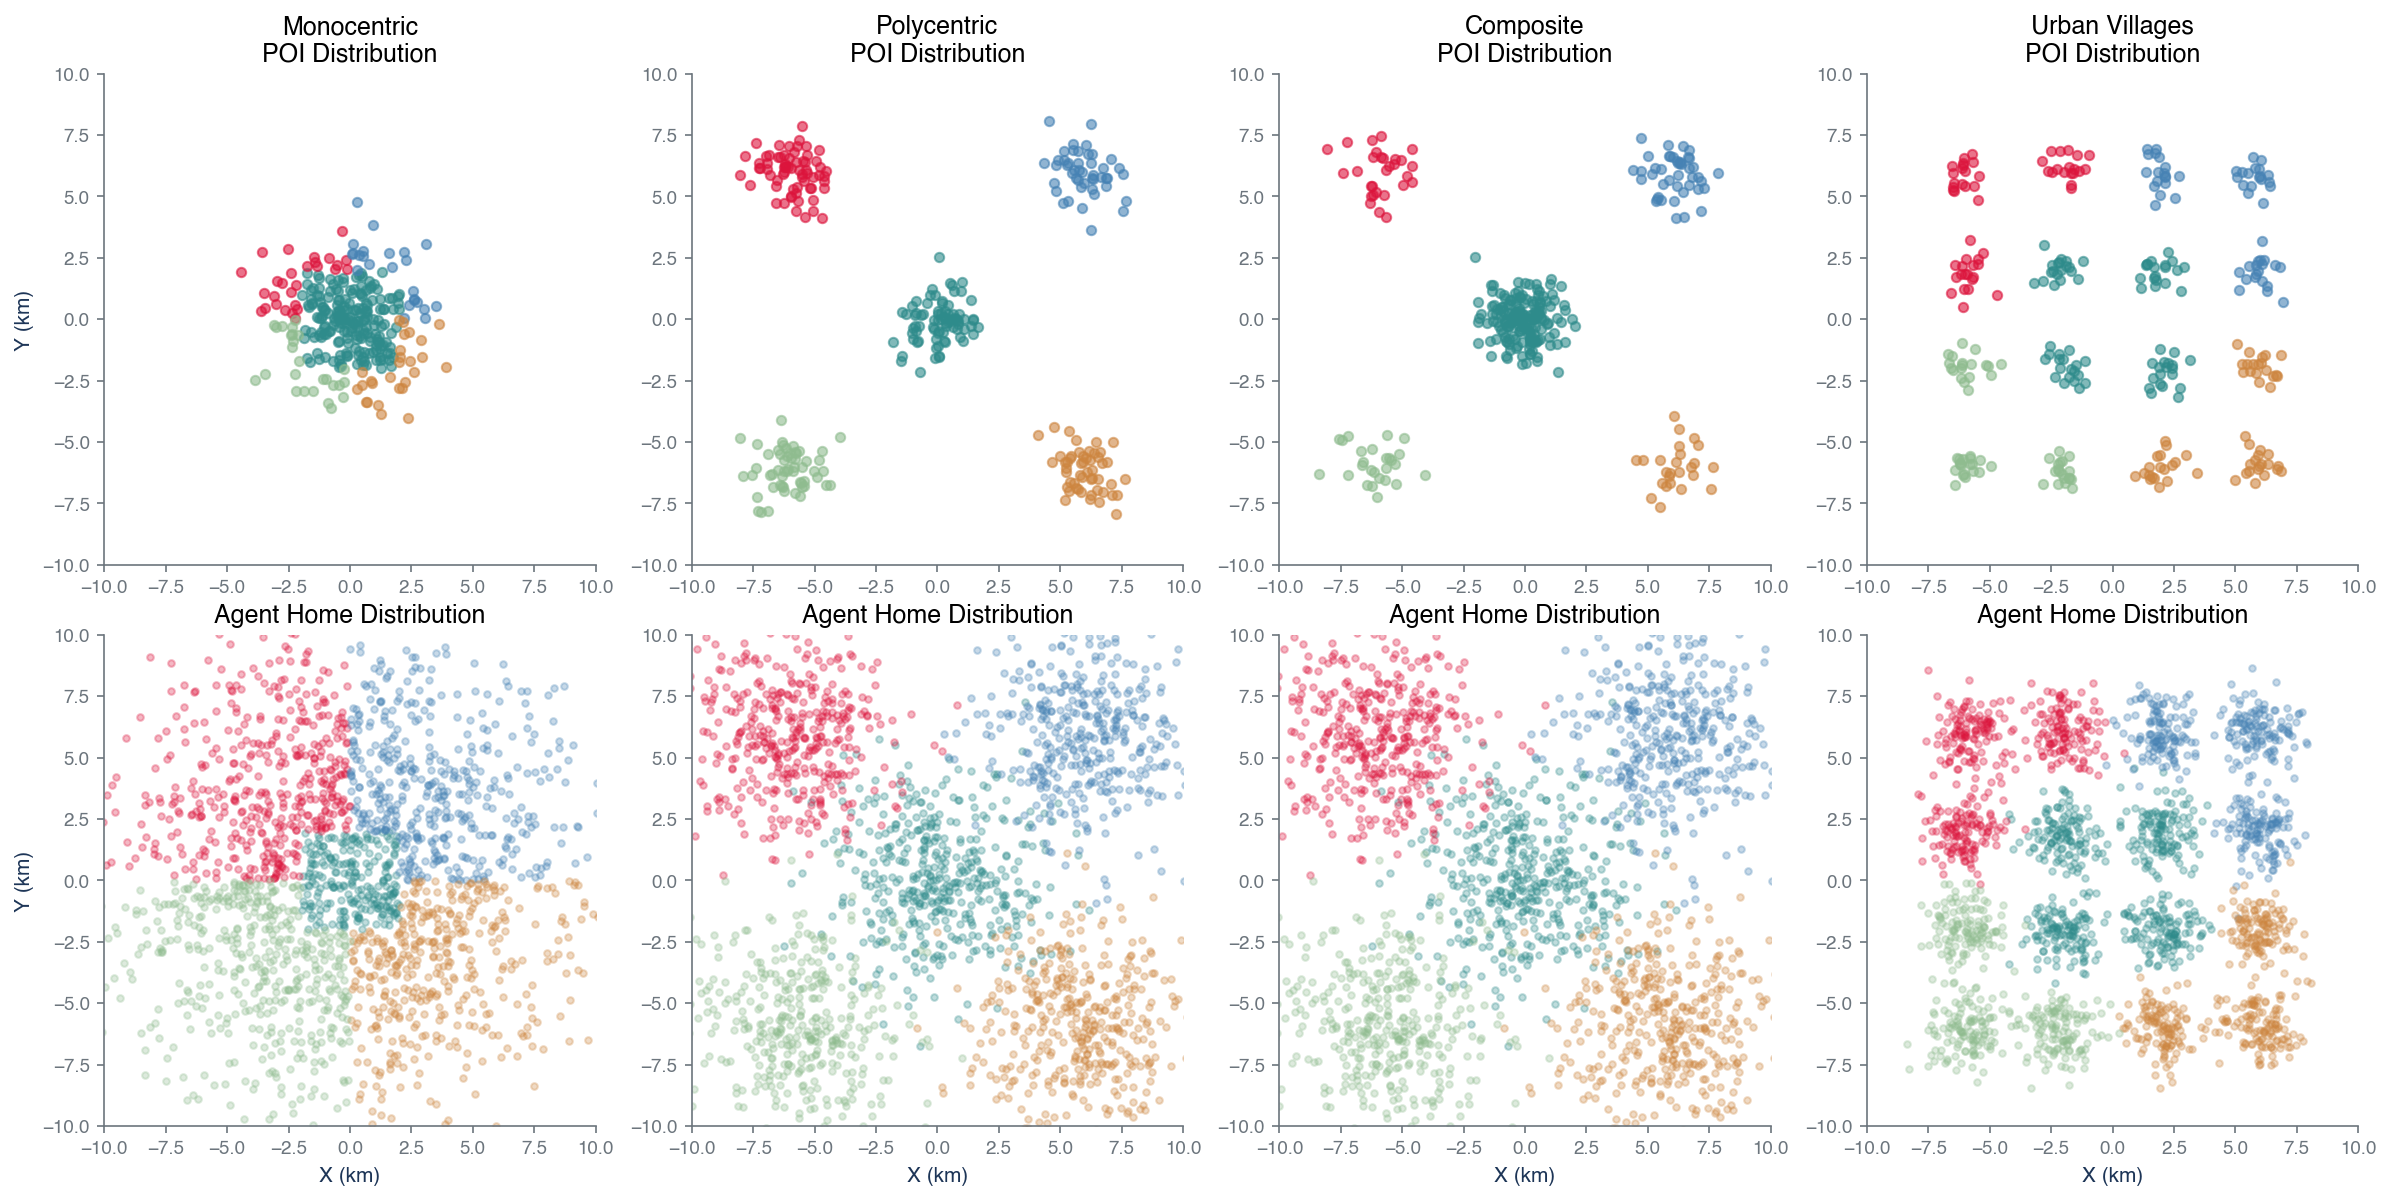

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Color palette
zone_colors = ['#2E8B8B', '#DC143C', '#4682B4', '#CD853F', '#8FBC8F']

for i, archetype in enumerate(ARCHETYPES):
    sim = results[archetype]
    poi_df = sim.poi_df
    agent_df = sim.agent_df
    
    # POI distribution (top row)
    ax = axes[0, i]
    for zone_id in sorted(poi_df['zone_id'].unique()):
        zone_pois = poi_df[poi_df['zone_id'] == zone_id]
        ax.scatter(zone_pois['x'], zone_pois['y'], 
                   c=zone_colors[zone_id], alpha=0.6, s=20,
                   label=zone_pois['zone_name'].iloc[0] if len(zone_pois) > 0 else '')
    ax.set_xlim(-CITY_EXTENT, CITY_EXTENT)
    ax.set_ylim(-CITY_EXTENT, CITY_EXTENT)
    ax.set_title(f'{archetype.replace("_", " ").title()}\nPOI Distribution')
    ax.set_aspect('equal')
    if i == 0:
        ax.set_ylabel('Y (km)')
    
    # Agent home distribution (bottom row)
    ax = axes[1, i]
    for zone_id in sorted(agent_df['zone_id'].unique()):
        zone_agents = agent_df[agent_df['zone_id'] == zone_id]
        ax.scatter(zone_agents['home_x'], zone_agents['home_y'],
                   c=zone_colors[zone_id], alpha=0.3, s=10)
    ax.set_xlim(-CITY_EXTENT, CITY_EXTENT)
    ax.set_ylim(-CITY_EXTENT, CITY_EXTENT)
    ax.set_title('Agent Home Distribution')
    ax.set_xlabel('X (km)')
    ax.set_aspect('equal')
    if i == 0:
        ax.set_ylabel('Y (km)')

plt.tight_layout()
plt.show()

## Compare Isolation Metrics

Experienced isolation measures how much agents interact with others from their own zone vs. other zones.

In [8]:
import pandas as pd
import numpy as np

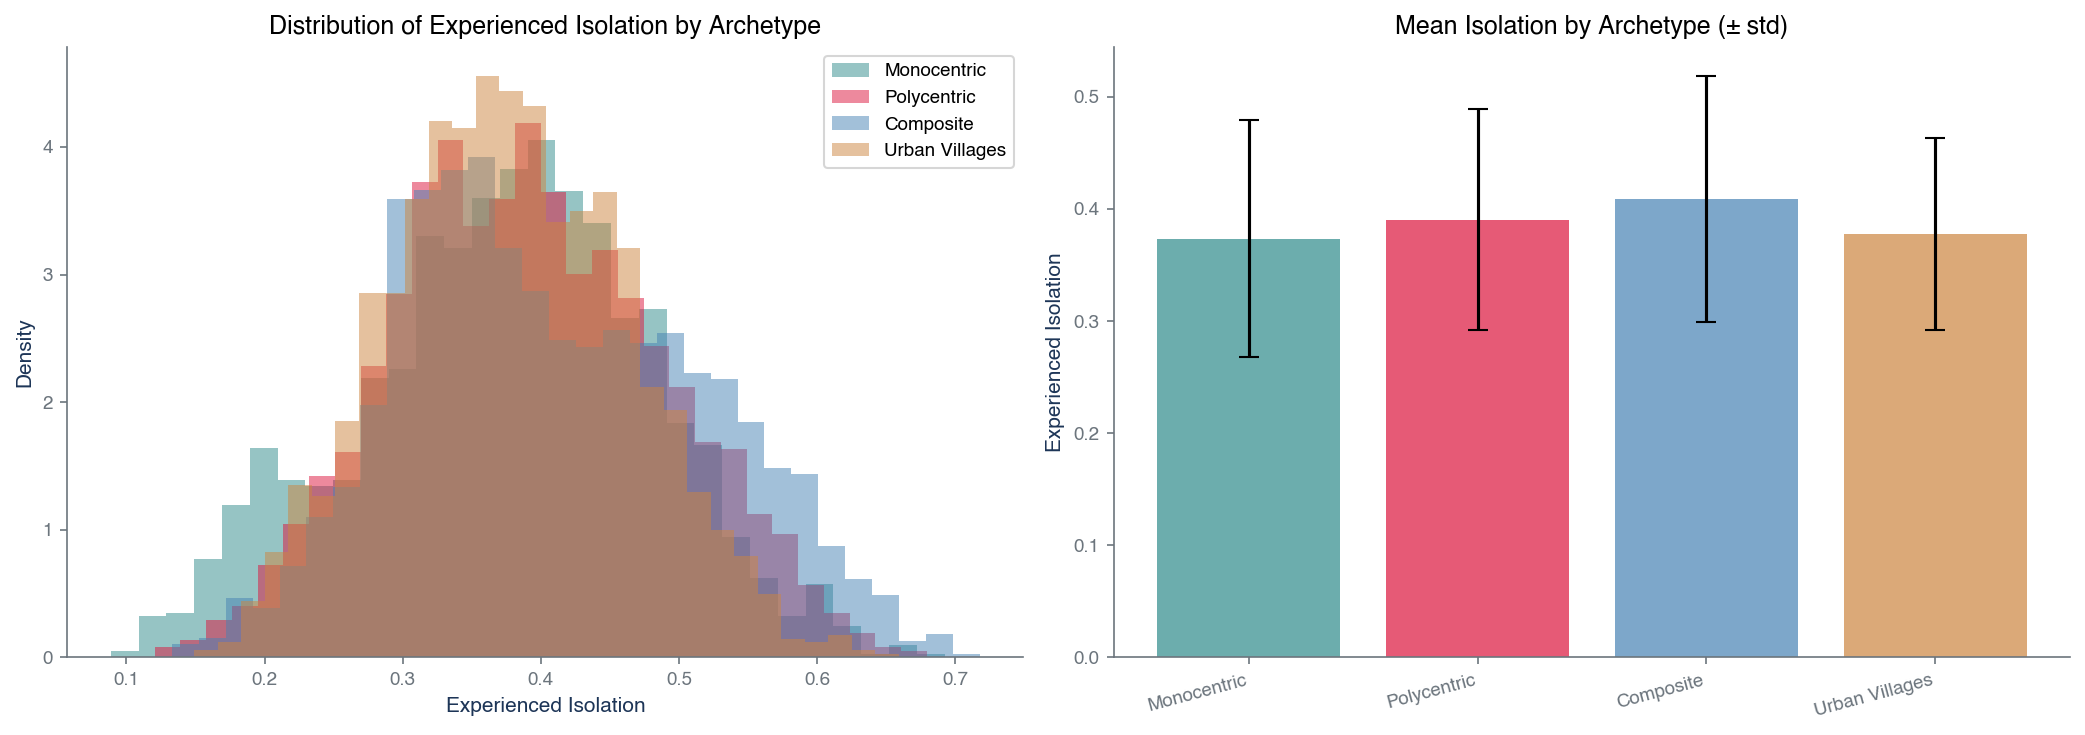


Isolation Statistics:
     Archetype     Mean      Std   Median      Min      Max
   Monocentric 0.373543 0.105937 0.379518 0.088639 0.692276
   Polycentric 0.390462 0.098644 0.387648 0.120360 0.679498
     Composite 0.408925 0.110078 0.395217 0.132837 0.717948
Urban Villages 0.377569 0.085803 0.373916 0.149027 0.659021


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation distributions
ax = axes[0]
colors = ['#2E8B8B', '#DC143C', '#4682B4', '#CD853F']
for i, archetype in enumerate(ARCHETYPES):
    isolation = results[archetype].isolation_df['experienced_isolation']
    ax.hist(isolation, bins=30, alpha=0.5, label=archetype.replace('_', ' ').title(),
            color=colors[i], density=True)
ax.set_xlabel('Experienced Isolation')
ax.set_ylabel('Density')
ax.set_title('Distribution of Experienced Isolation by Archetype')
ax.legend()

# Summary statistics
ax = axes[1]
stats_data = []
for archetype in ARCHETYPES:
    isolation = results[archetype].isolation_df['experienced_isolation']
    stats_data.append({
        'Archetype': archetype.replace('_', ' ').title(),
        'Mean': isolation.mean(),
        'Std': isolation.std(),
        'Median': isolation.median(),
        'Min': isolation.min(),
        'Max': isolation.max()
    })

stats_df = pd.DataFrame(stats_data)
x = np.arange(len(ARCHETYPES))
ax.bar(x, stats_df['Mean'], yerr=stats_df['Std'], capsize=5, color=colors, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(stats_df['Archetype'], rotation=15, ha='right')
ax.set_ylabel('Experienced Isolation')
ax.set_title('Mean Isolation by Archetype (± std)')

plt.tight_layout()
plt.show()

print("\nIsolation Statistics:")
print(stats_df.to_string(index=False))

## Exposure Matrices

Visualize inter-zone contact patterns. Higher values indicate more exposure between zones.

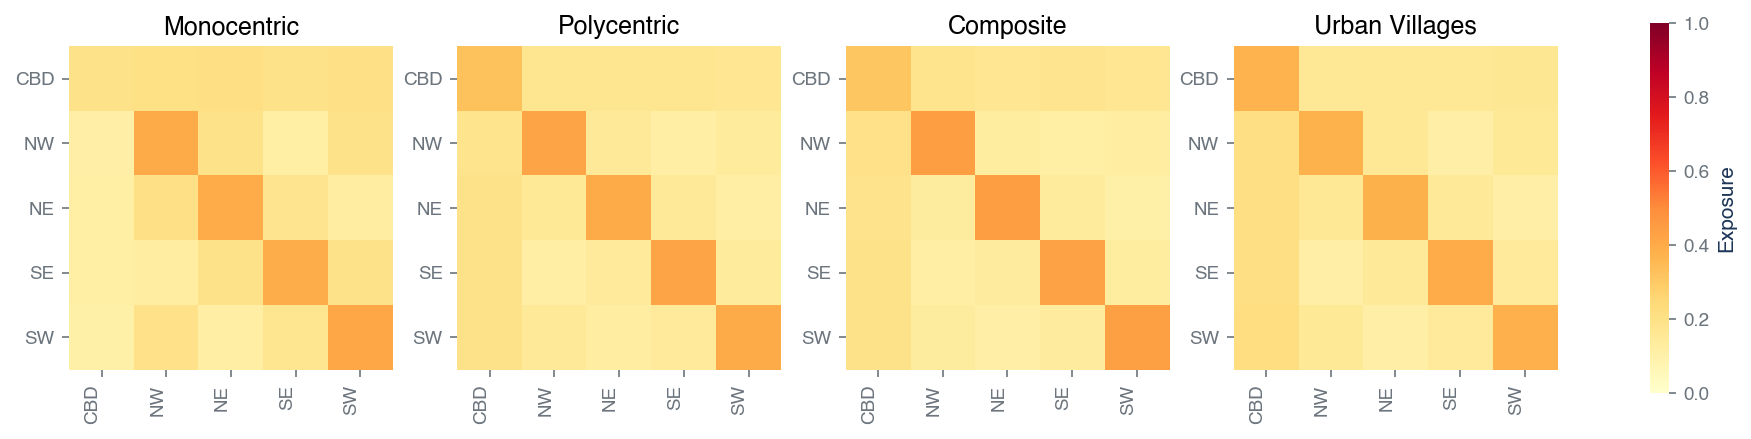

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
nzone_names = ['CBD', 'NW', 'NE', 'SE', 'SW']

for i, archetype in enumerate(ARCHETYPES):
    ax = axes[i]
    exposure = results[archetype].exposure_df
    # Extract numeric values (drop origin_zone column if present)
    if 'origin_zone' in exposure.columns:
        exposure_vals = exposure.drop(columns=['origin_zone']).values
    else:
        exposure_vals = exposure.values
    
    n_zones = exposure_vals.shape[0]
    im = ax.imshow(exposure_vals, cmap='YlOrRd', vmin=0, vmax=1)

    for side in ['left', 'right', 'top', 'bottom']:
        ax.spines[side].set_visible(False)
    
    ax.set_xticks(range(n_zones))
    ax.set_xticklabels(nzone_names[:n_zones], rotation=90, ha='right')
    ax.set_yticks(range(n_zones))
    ax.set_yticklabels(nzone_names[:n_zones])
    ax.set_title(archetype.replace('_', ' ').title(), weight='bold')
    
# add a colorbar 0-1 scaled, without a black border/frame on the bar
cbar = fig.colorbar(im, ax=axes, shrink=0.8, label='Exposure')
cbar.outline.set_visible(False)

plt.show()

## Isolation Evolution Over Time

Track how isolation stabilizes as the simulation progresses.

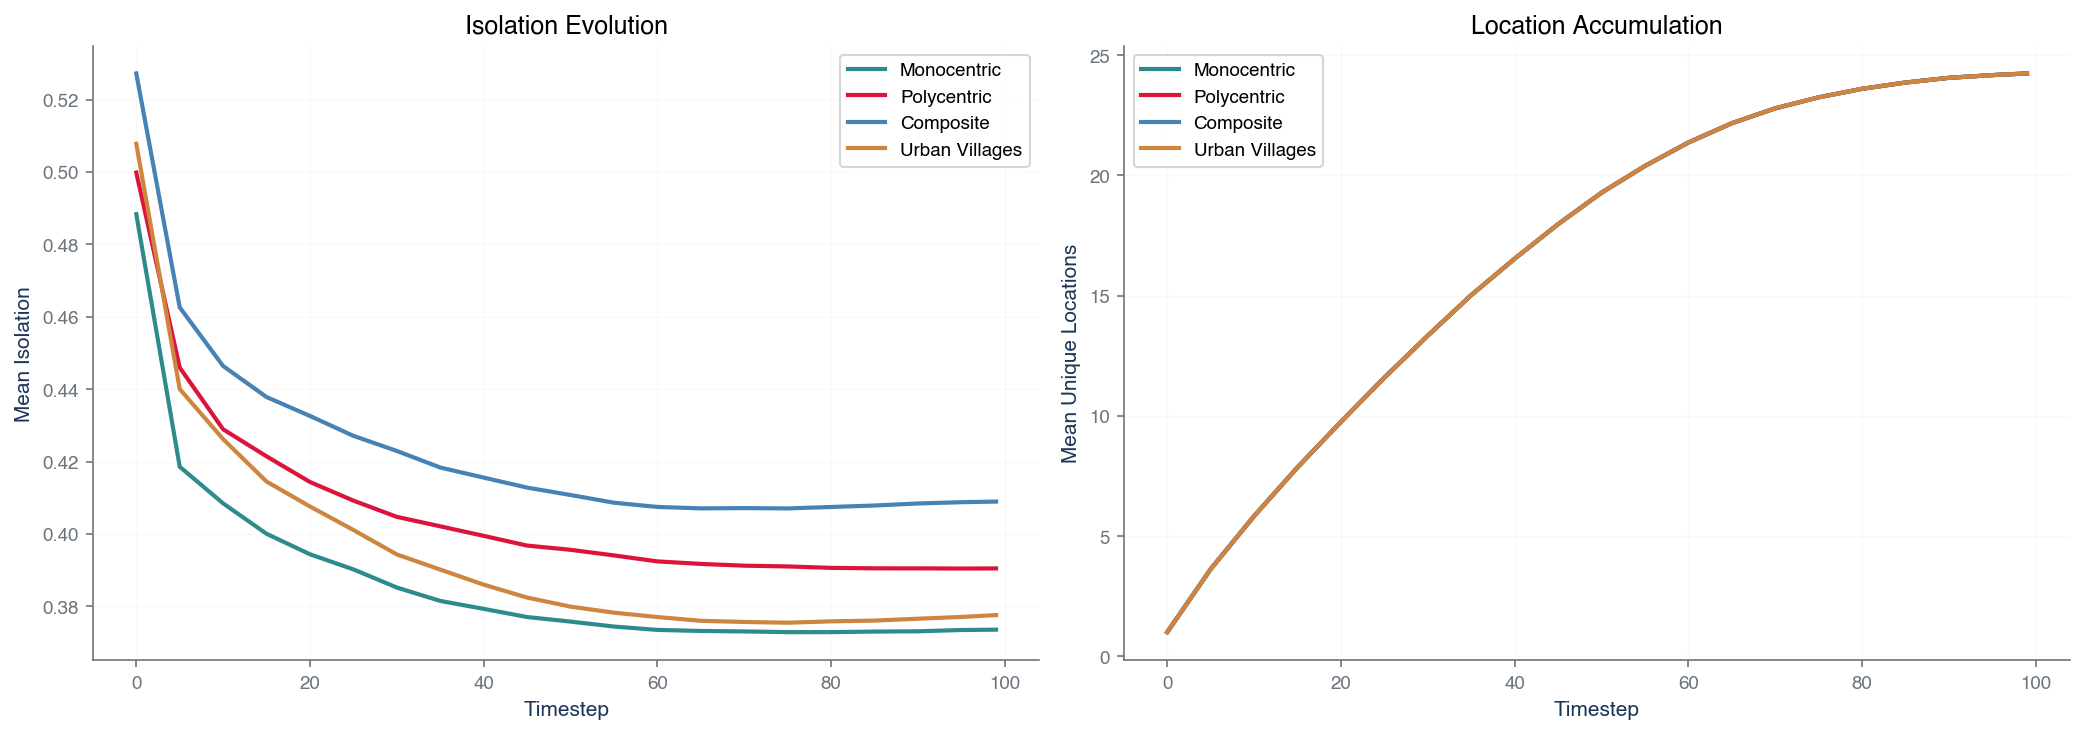

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2E8B8B', '#DC143C', '#4682B4', '#CD853F']

# Mean isolation over time
ax = axes[0]
for i, archetype in enumerate(ARCHETYPES):
    evolution = results[archetype].evolution_df
    ax.plot(evolution['timestep'], evolution['mean_isolation'], 
            label=archetype.replace('_', ' ').title(), color=colors[i], linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Mean Isolation')
ax.set_title('Isolation Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Unique locations over time
ax = axes[1]
for i, archetype in enumerate(ARCHETYPES):
    evolution = results[archetype].evolution_df
    ax.plot(evolution['timestep'], evolution['mean_unique_locations'],
            label=archetype.replace('_', ' ').title(), color=colors[i], linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Mean Unique Locations')
ax.set_title('Location Accumulation')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Mobility Range: Radius of Gyration

Compare how far agents travel across different urban forms.

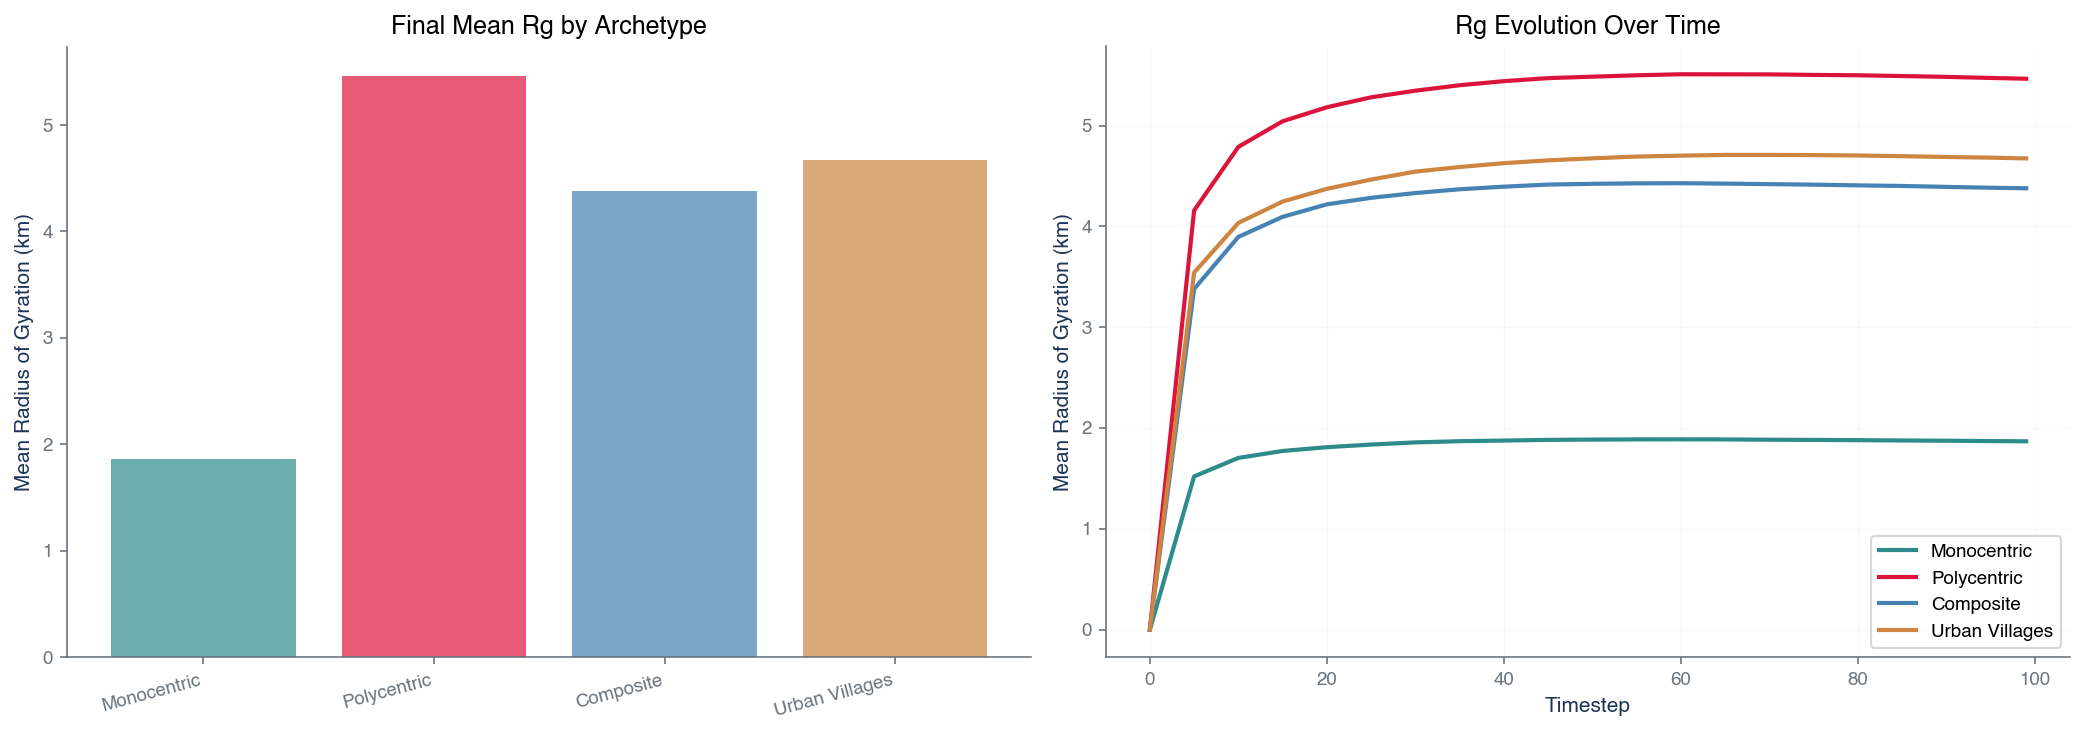

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2E8B8B', '#DC143C', '#4682B4', '#CD853F']

# Rg distribution (histogram)
ax = axes[0]
for i, archetype in enumerate(ARCHETYPES):
    evolution = results[archetype].evolution_df
    if 'mean_rg' in evolution.columns:
        final_rg = evolution['mean_rg'].iloc[-1]
        ax.bar(i, final_rg, color=colors[i], alpha=0.7,
               label=archetype.replace('_', ' ').title())

ax.set_xticks(range(len(ARCHETYPES)))
ax.set_xticklabels([a.replace('_', ' ').title() for a in ARCHETYPES], rotation=15, ha='right')
ax.set_ylabel('Mean Radius of Gyration (km)')
ax.set_title('Final Mean Rg by Archetype')

# Rg evolution
ax = axes[1]
for i, archetype in enumerate(ARCHETYPES):
    evolution = results[archetype].evolution_df
    if 'mean_rg' in evolution.columns:
        ax.plot(evolution['timestep'], evolution['mean_rg'],
                label=archetype.replace('_', ' ').title(), color=colors[i], linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Mean Radius of Gyration (km)')
ax.set_title('Rg Evolution Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Zone-Level Analysis

Break down isolation by zone for each archetype.

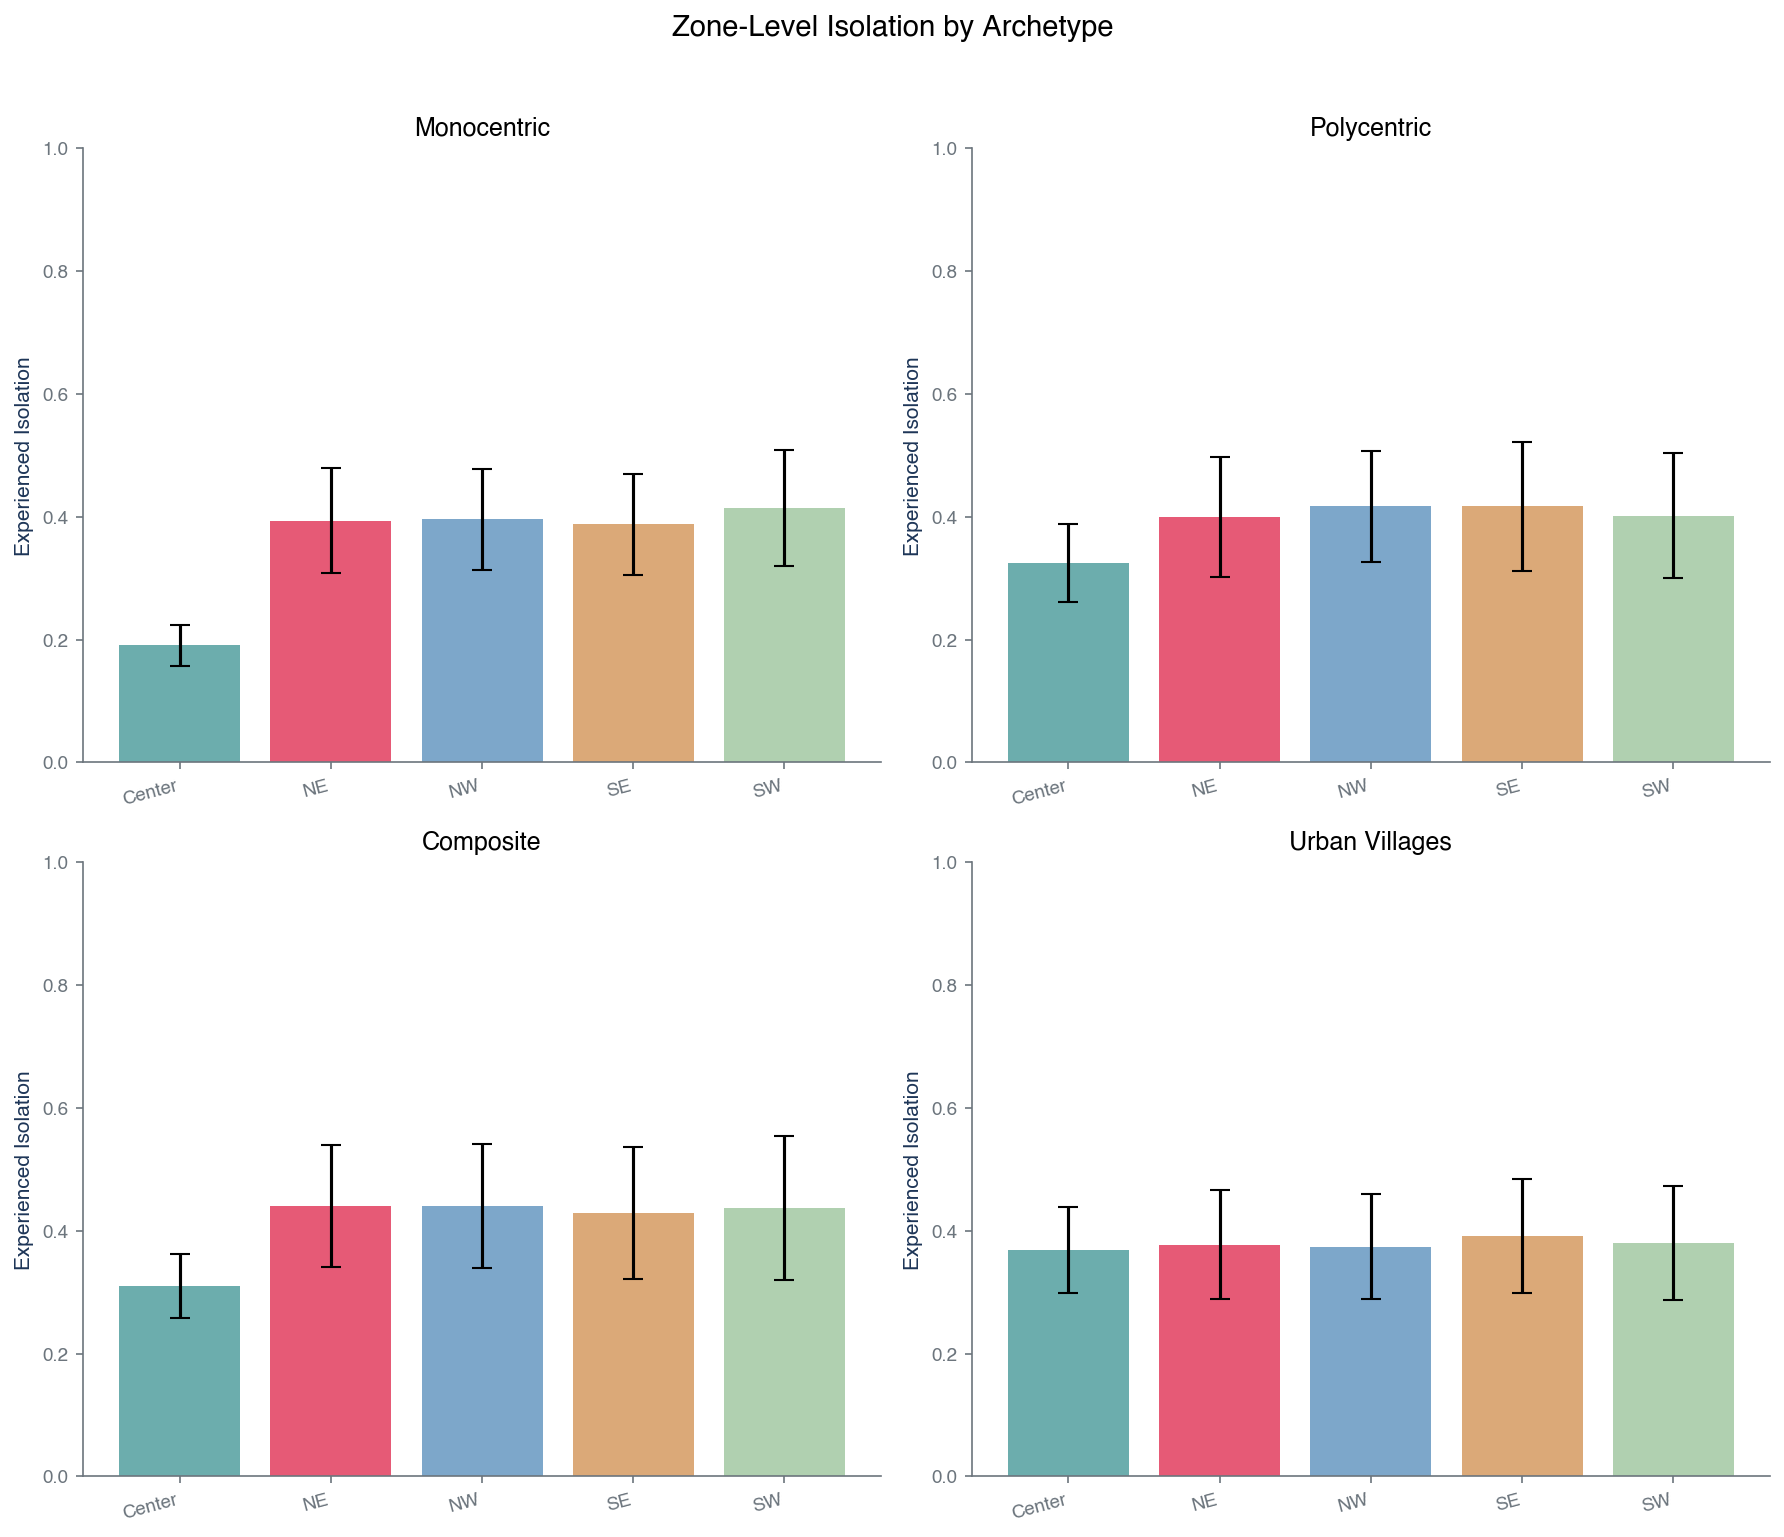

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
zone_colors = ['#2E8B8B', '#DC143C', '#4682B4', '#CD853F', '#8FBC8F']
zone_names = ['Center', 'NW', 'NE', 'SE', 'SW']

for idx, archetype in enumerate(ARCHETYPES):
    ax = axes[idx // 2, idx % 2]
    isolation_df = results[archetype].isolation_df
    
    # Group by zone
    zone_isolation = isolation_df.groupby('zone_name')['experienced_isolation'].agg(['mean', 'std'])
    
    x = np.arange(len(zone_isolation))
    bars = ax.bar(x, zone_isolation['mean'], yerr=zone_isolation['std'], 
                  capsize=5, color=zone_colors[:len(zone_isolation)], alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(zone_isolation.index, rotation=15, ha='right')
    ax.set_ylabel('Experienced Isolation')
    ax.set_title(f'{archetype.replace("_", " ").title()}')
    ax.set_ylim(0, 1)

fig.suptitle('Zone-Level Isolation by Archetype', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary Comparison

In [14]:
summary_data = []

for archetype in ARCHETYPES:
    sim = results[archetype]
    isolation = sim.isolation_df['experienced_isolation']
    evolution = sim.evolution_df
    # Calculate final metrics
    final_row = evolution.iloc[-1]
    # Get diagonal exposure (self-zone exposure)
    exposure = sim.exposure_df
    if 'origin_zone' in exposure.columns:
        exposure_vals = exposure.drop(columns=['origin_zone']).values
    else:
        exposure_vals = exposure.values
    
    diag_exposure = np.diag(exposure_vals).mean()
    summary_data.append({'Archetype': archetype.replace('_', ' ').title(), 'Mean Isolation': f"{isolation.mean():.3f}", 'Isolation Std': f"{isolation.std():.3f}", 'Mean Unique Locs': f"{final_row['mean_unique_locations']:.1f}", 'Mean Rg (km)': f"{final_row.get('mean_rg', 0):.2f}" if 'mean_rg' in final_row else 'N/A', 'Diagonal Exposure': f"{diag_exposure:.3f}"})

## Full Diagnostics Dashboard

Generate the complete 12-panel diagnostics for one archetype (polycentric as the default).

Generating full diagnostics for polycentric archetype...


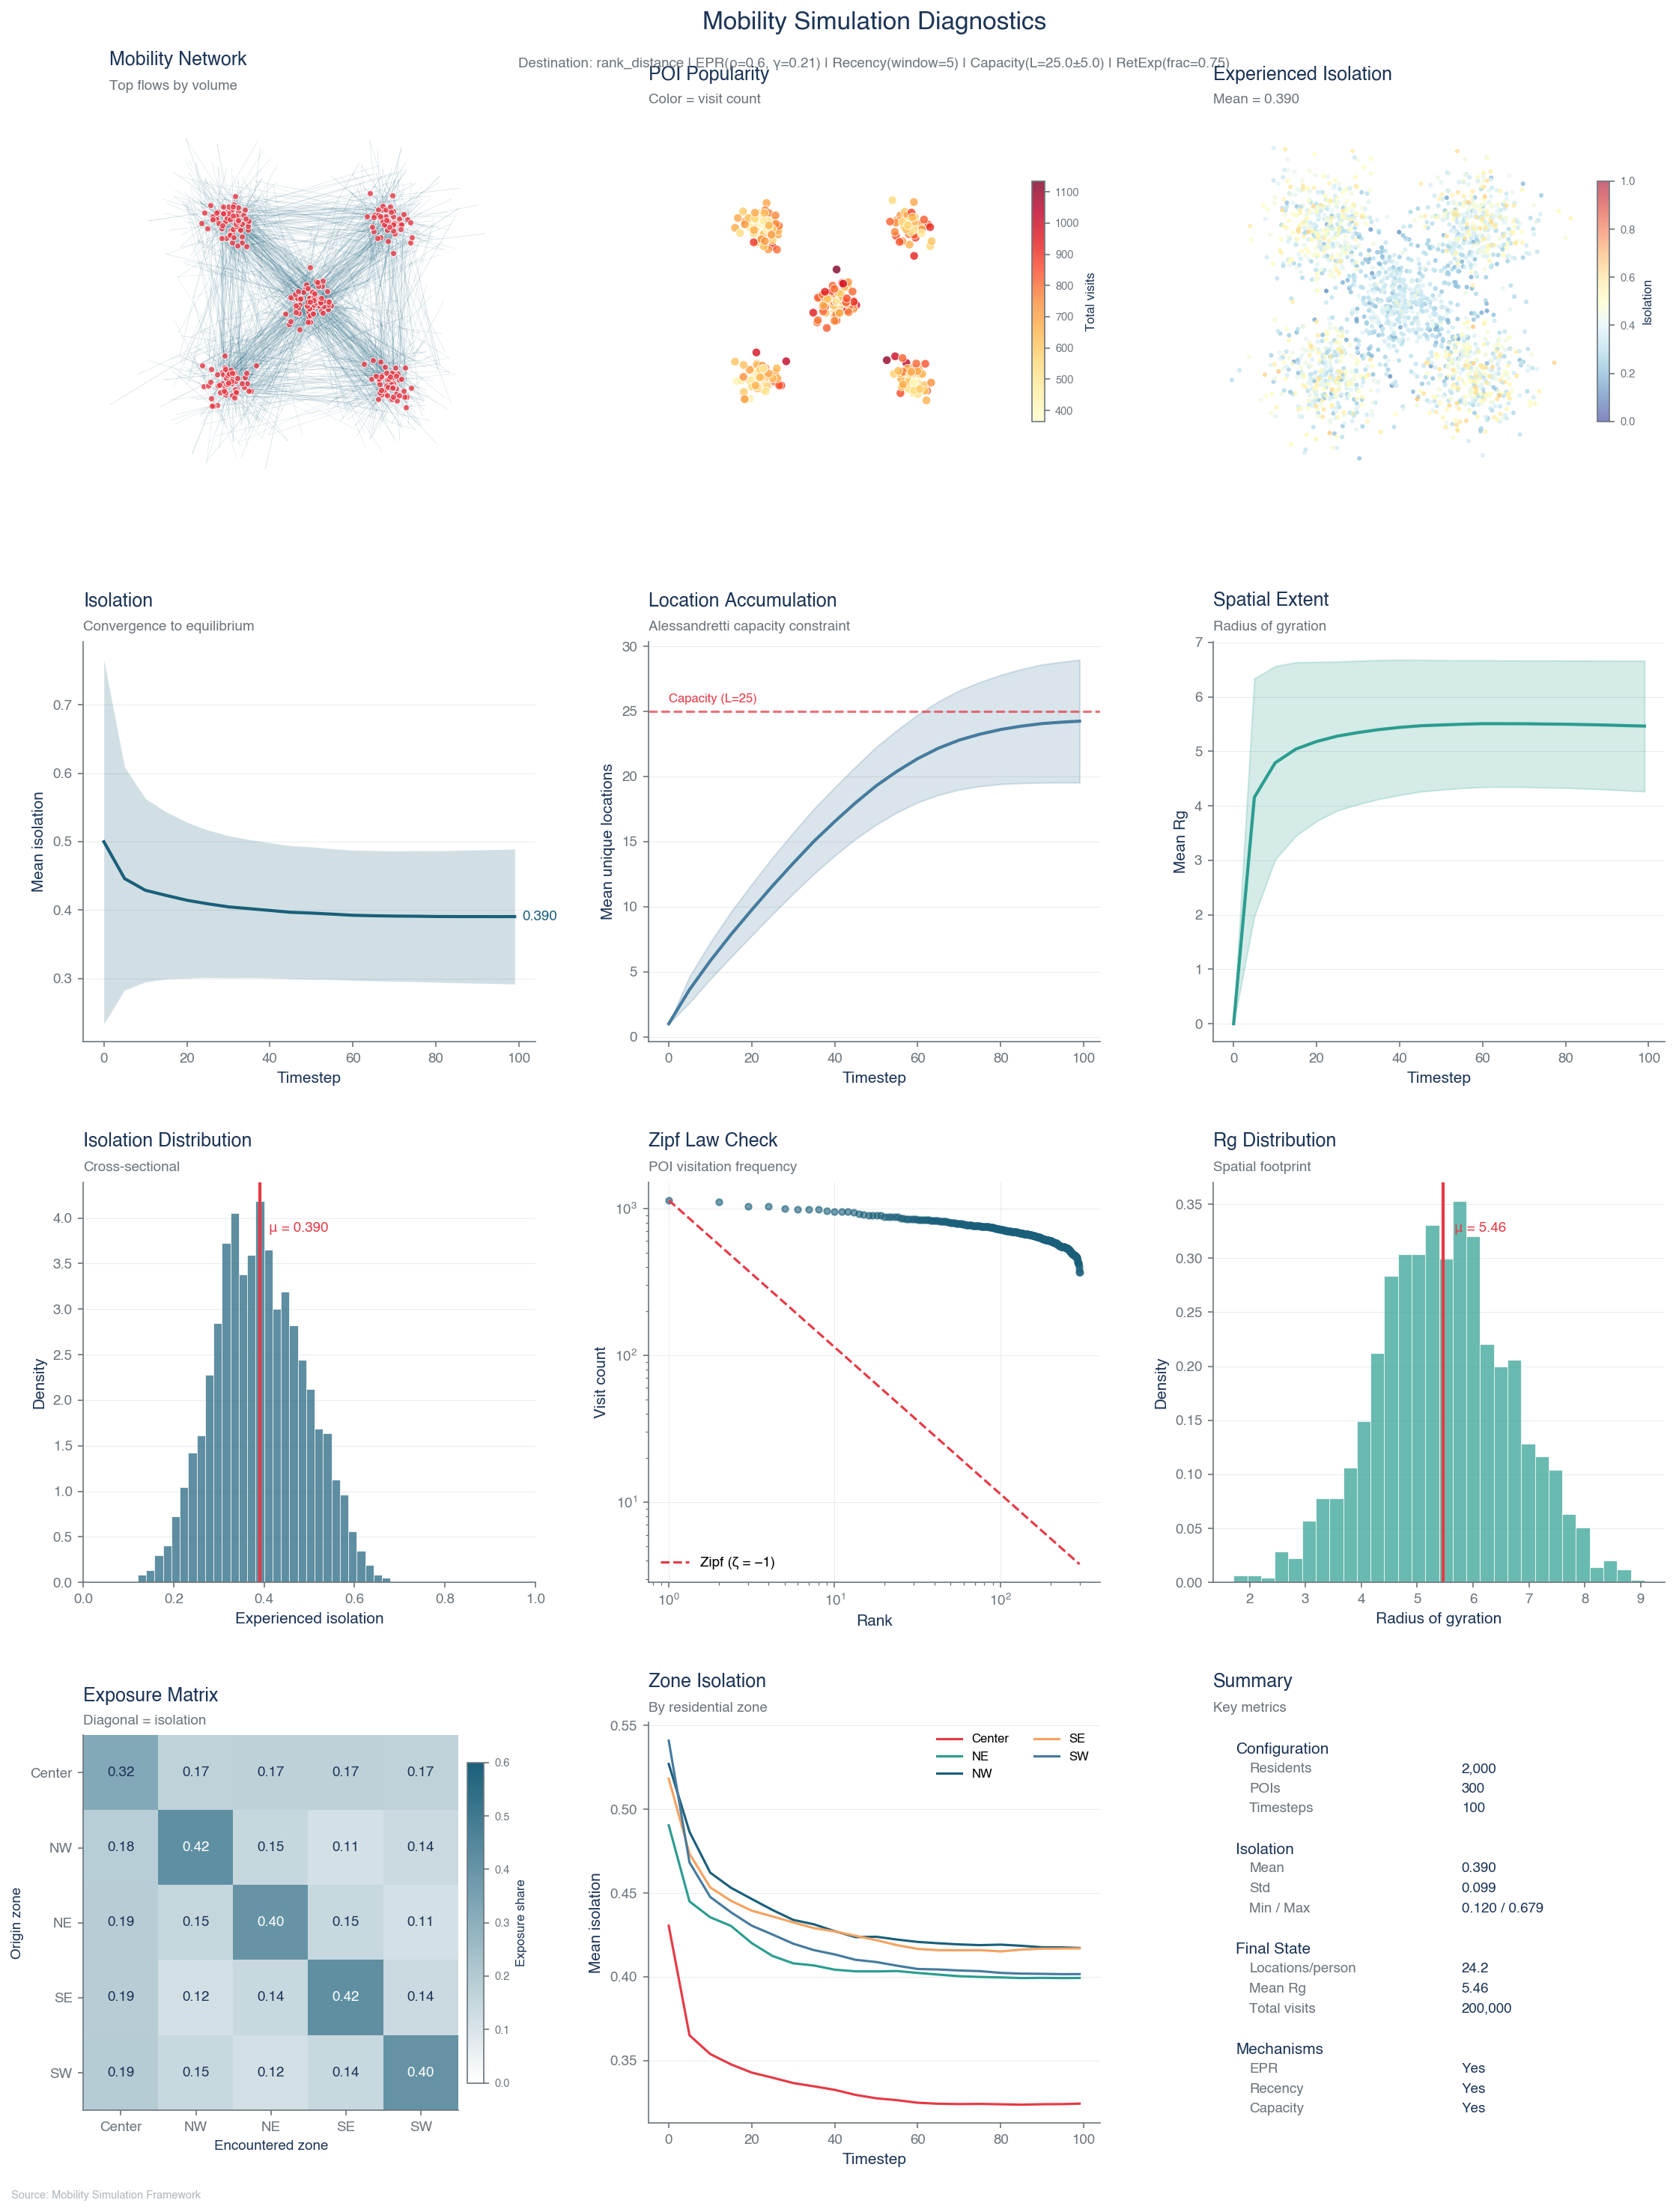

In [15]:
# Generate full diagnostics for polycentric city
print("Generating full diagnostics for polycentric archetype...")
results['polycentric'].plot_diagnostics()